
 # Financial Transactions Dataset: Analytics and Fraud Detection

## Data understanding and Cleaning

In [3]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("computingvictor/transactions-fraud-datasets")

# print("Path to dataset files:", path)

In [4]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import json



In [5]:
df_cards = pd.read_csv('cards_data.csv')
df_cards['card_on_dark_web'].value_counts()
df_cards

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6141,5361,185,Amex,Credit,300609782832003,01/2024,663,YES,1,$6900,11/2000,2013,No
6142,2711,185,Visa,Credit,4718517475996018,01/2021,492,YES,2,$5700,04/2012,2012,No
6143,1305,1007,Mastercard,Credit,5929512204765914,08/2020,237,NO,2,$9200,02/2012,2012,No
6144,743,1110,Mastercard,Debit,5589768928167462,01/2020,630,YES,1,$28074,01/2020,2020,No


In [6]:
df_cards.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     6146 non-null   int64 
 1   client_id              6146 non-null   int64 
 2   card_brand             6146 non-null   object
 3   card_type              6146 non-null   object
 4   card_number            6146 non-null   int64 
 5   expires                6146 non-null   object
 6   cvv                    6146 non-null   int64 
 7   has_chip               6146 non-null   object
 8   num_cards_issued       6146 non-null   int64 
 9   credit_limit           6146 non-null   object
 10  acct_open_date         6146 non-null   object
 11  year_pin_last_changed  6146 non-null   int64 
 12  card_on_dark_web       6146 non-null   object
dtypes: int64(6), object(7)
memory usage: 624.3+ KB


In [7]:
df_cards['has_chip'] = df_cards['has_chip'].map({'YES':True,'NO':False})


In [8]:
df_cards['card_on_dark_web'] = df_cards['card_on_dark_web'].map({'Yes':True,'No':False})

In [9]:
df_cards['expires'] = pd.to_datetime(df_cards['expires'], format='%m/%Y', errors='coerce')
df_cards['acct_open_date'] = pd.to_datetime(df_cards['acct_open_date'], format='%m/%Y', errors='coerce')
df_cards['year_pin_last_changed'] = pd.to_datetime(df_cards['year_pin_last_changed'], format='%Y', errors='coerce')
df_cards['credit_limit'] = pd.to_numeric(df_cards['credit_limit'].str.replace('$','', regex=False), errors='coerce')
df_cards['credit_limit'] 

0       24295
1       21968
2       46414
3       12400
4          28
        ...  
6141     6900
6142     5700
6143     9200
6144    28074
6145    14400
Name: credit_limit, Length: 6146, dtype: int64

In [10]:
df_cards = df_cards.rename(columns={'id':'card_id'})

In [11]:
df_transaction = pd.read_csv('transactions_data.csv')
df_transaction.head(5)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN


In [12]:
df_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            object 
 2   client_id       int64  
 3   card_id         int64  
 4   amount          object 
 5   use_chip        object 
 6   merchant_id     int64  
 7   merchant_city   object 
 8   merchant_state  object 
 9   zip             float64
 10  mcc             int64  
 11  errors          object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.2+ GB


In [13]:
with open('train_fraud_labels.json') as f:
    fraud_labels = json.load(f)['target']

df_isFraud = pd.DataFrame(
    fraud_labels.items(),
    columns=['id','is_fraud']
)

df_isFraud.head()

,id,is_fraud
0,10649266,No
1,23410063,No
2,9316588,No
3,12478022,No
4,9558530,No


In [14]:
df_isFraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8914963 entries, 0 to 8914962
Data columns (total 2 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   id        object
 1   is_fraud  object
dtypes: object(2)
memory usage: 136.0+ MB


In [15]:
# df_isFraud
# Make is_fraud boolean
df_isFraud['is_fraud'] = df_isFraud['is_fraud'].map({
    'Yes': True,
    'No': False
})

In [16]:
df_isFraud['id'] = df_isFraud['id'].astype('int64')

In [17]:
print(df_isFraud.head())
print('----------')
print(df_isFraud.info())


         id  is_fraud
0  10649266     False
1  23410063     False
2   9316588     False
3  12478022     False
4   9558530     False
----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8914963 entries, 0 to 8914962
Data columns (total 2 columns):
 #   Column    Dtype
---  ------    -----
 0   id        int64
 1   is_fraud  bool 
dtypes: bool(1), int64(1)
memory usage: 76.5 MB
None


In [18]:
# df_transaction

df_transaction['date'] = pd.to_datetime(df_transaction['date'])
df_transaction['amount'] = pd.to_numeric(df_transaction['amount'].str.replace('$','', regex=False), errors='coerce')

In [19]:
df_transaction['use_chip'].value_counts()

use_chip
Swipe Transaction     6967185
Chip Transaction      4780818
Online Transaction    1557912
Name: count, dtype: int64

In [20]:
# Connect mcc code to df_transactions dataframe

with open('mcc_codes.json') as f:
    mcc_codes = json.load(f)

df_transaction['mcc'] = df_transaction['mcc'].astype(str).map(mcc_codes)

In [21]:
df_transaction['mcc']

0                            Miscellaneous Food Stores
1                                    Department Stores
2                                       Money Transfer
3                                       Money Transfer
4                Drinking Places (Alcoholic Beverages)
                               ...                    
13305910                     Miscellaneous Food Stores
13305911            Digital Goods - Media, Books, Apps
13305912    Utilities - Electric, Gas, Water, Sanitary
13305913                  Grocery Stores, Supermarkets
13305914            Package Stores, Beer, Wine, Liquor
Name: mcc, Length: 13305915, dtype: object

In [22]:
df_transaction.head(3)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,Miscellaneous Food Stores,NaN
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,Department Stores,NaN
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,Money Transfer,NaN


In [23]:
fraud_merchant = df_transaction.merge(df_isFraud,on='id',how='left')
fraud_merchant.head(3)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,is_fraud
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,Miscellaneous Food Stores,NaN,False
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,Department Stores,NaN,False
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,Money Transfer,NaN,False


In [24]:
# Chech the 2 Datasets seperately
df_fraudTransaction = fraud_merchant[fraud_merchant['is_fraud'] == True]
df_nonFraudTransaction = fraud_merchant[fraud_merchant['is_fraud'] == False]

In [25]:
comparison_amount = pd.DataFrame({
    "Fraud": df_fraudTransaction["amount"].describe(),
    "Non-Fraud": df_nonFraudTransaction["amount"].describe()
})

comparison_amount

,Fraud,Non-Fraud
count,13332.000000,8.901631e+06
mean,110.234682,4.284861e+01
std,213.736207,8.112535e+01
min,-500.000000,-5.000000e+02
25%,17.835000,8.920000e+00
50%,69.975000,2.895000e+01
75%,148.492500,6.357000e+01
max,4978.450000,6.613440e+03


In [26]:
fraud_merchant['is_fraud'].isna().sum()

4390952

In [27]:
# Find Fraud rate by the hour of the day
fraud_only_df = fraud_merchant[fraud_merchant['is_fraud'] == True].copy()

fraud_only_df['hour'] = fraud_only_df['date'].dt.hour

fraud_by_hour = (
    fraud_only_df
    .groupby('hour')
    .size()
    .reindex(range(24), fill_value=0)
    .reset_index(name='fraud_transactions')
)

fraud_by_hour['fraud_percent'] = (
    fraud_by_hour['fraud_transactions'] / fraud_by_hour['fraud_transactions'].sum() * 100
).round(2)

fraud_by_hour

,hour,fraud_transactions,fraud_percent
0,0,13,0.10
1,1,38,0.29
2,2,38,0.29
3,3,107,0.80
4,4,143,1.07
5,5,242,1.82
6,6,455,3.41
7,7,541,4.06
8,8,530,3.98
9,9,856,6.42


In [28]:
# Find Fraud rate by the day

fraud_only_df['day'] = fraud_only_df['date'].dt.day_name()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday","Friday", "Saturday", "Sunday"]

fraud_by_day = fraud_only_df.groupby('day').size().reindex(day_order, fill_value=0).reset_index(name='fraud_transactions')

fraud_by_day['fraud_percentage'] = (fraud_by_day['fraud_transactions'] / fraud_by_day['fraud_transactions'].sum() * 100).round(2)

fraud_by_day

,day,fraud_transactions,fraud_percentage
0,Monday,1747,13.10
1,Tuesday,2037,15.28
2,Wednesday,1102,8.27
3,Thursday,2082,15.62
4,Friday,2284,17.13
5,Saturday,1434,10.76
6,Sunday,2646,19.85


In [29]:
# Keep only the data that have the label 'is_fraud'

fraud_merchant_labeled = fraud_merchant[fraud_merchant['is_fraud'].notna()].copy()

In [30]:
fraud_merchant_labeled.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,is_fraud
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,Miscellaneous Food Stores,NaN,False
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,Department Stores,NaN,False
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,Money Transfer,NaN,False
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,Drinking Places (Alcoholic Beverages),NaN,False
5,7475333,2010-01-01 00:07:00,1807,165,4.81,Swipe Transaction,20519,Bronx,NY,10464.0,Book Stores,NaN,False


In [31]:
merchant_summary = (
    fraud_merchant_labeled
    .groupby('mcc')
    .agg(
        total_transactions=('id', 'count'),
        fraud_transactions=('is_fraud', 'sum')
    )
    .reset_index()
)

merchant_summary['fraud_rate'] = (
    merchant_summary['fraud_transactions'] / merchant_summary['total_transactions'] * 100
)

merchant_summary

,mcc,total_transactions,fraud_transactions,fraud_rate
0,"Accounting, Auditing, and Bookkeeping Services",2354,0,0.0
1,Airlines,1913,38,1.986409
2,"Amusement Parks, Carnivals, Circuses",7735,123,1.590175
3,Antique Shops,3977,86,2.162434
4,"Artist Supply Stores, Craft Shops",45281,78,0.172258
...,...,...,...,...
103,Upholstery and Drapery Stores,1894,14,0.739176
104,"Utilities - Electric, Gas, Water, Sanitary",162371,0,0.0
105,Welding Repair,5491,42,0.764888
106,Wholesale Clubs,403343,991,0.245697


In [32]:
# User dataframe

user_df = pd.read_csv('users_data.csv')
user_df.head(2)

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5


In [33]:
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   current_age        2000 non-null   int64  
 2   retirement_age     2000 non-null   int64  
 3   birth_year         2000 non-null   int64  
 4   birth_month        2000 non-null   int64  
 5   gender             2000 non-null   object 
 6   address            2000 non-null   object 
 7   latitude           2000 non-null   float64
 8   longitude          2000 non-null   float64
 9   per_capita_income  2000 non-null   object 
 10  yearly_income      2000 non-null   object 
 11  total_debt         2000 non-null   object 
 12  credit_score       2000 non-null   int64  
 13  num_credit_cards   2000 non-null   int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 218.9+ KB


In [34]:
user_df['per_capita_income'] = pd.to_numeric(user_df['per_capita_income'].str.replace('$','',regex=False), errors='coerce')
user_df['yearly_income'] = pd.to_numeric(user_df['yearly_income'].str.replace('$','', regex=False), errors='coerce')
user_df['total_debt'] = pd.to_numeric(user_df['total_debt'].str.replace('$',''), errors='coerce')
user_df.head(3)


,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,29278,59696,127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,37891,77254,191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,22681,33483,196,698,5


In [35]:
user_df = user_df.rename(columns={'id':'user_id'})

In [36]:
user_df.head(4)

,user_id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,29278,59696,127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,37891,77254,191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,22681,33483,196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,163145,249925,202328,722,4


In [37]:
user_df['gender'].value_counts()

gender
Female    1016
Male       984
Name: count, dtype: int64

In [38]:
df_cards.head()

,card_id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,2022-12-01,623,True,2,24295,2002-09-01,2008-01-01,False
1,2731,825,Visa,Debit,4956965974959986,2020-12-01,393,True,2,21968,2014-04-01,2014-01-01,False
2,3701,825,Visa,Debit,4582313478255491,2024-02-01,719,True,2,46414,2003-07-01,2004-01-01,False
3,42,825,Visa,Credit,4879494103069057,2024-08-01,693,False,1,12400,2003-01-01,2012-01-01,False
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,2009-03-01,75,True,1,28,2008-09-01,2009-01-01,False


In [39]:
# Prepare data for 'Fraud rate by age group'

cards_selected_df = df_cards[['card_id','card_brand','card_type','credit_limit','has_chip']]

fraud_by_age_df = fraud_merchant[fraud_merchant['is_fraud'].notna()].copy()

fraud_by_age_df = fraud_by_age_df.merge(
    cards_selected_df,
    on='card_id',
    how='left',
    validate='many_to_one'
)

In [40]:
fraud_by_age_df.head(2)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,is_fraud,card_brand,card_type,credit_limit,has_chip
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,Miscellaneous Food Stores,NaN,False,Mastercard,Debit (Prepaid),55,True
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,Department Stores,NaN,False,Mastercard,Credit,9100,True


In [41]:
user_selected_df = user_df[['user_id', 'current_age']].rename(columns={'user_id':'client_id'}).copy()

fraud_by_age_df = fraud_by_age_df.merge(
    user_selected_df,
    on='client_id',
    how='left',
    validate='many_to_one'
)
fraud_by_age_df.head(4)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,is_fraud,card_brand,card_type,credit_limit,has_chip,current_age
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,Miscellaneous Food Stores,NaN,False,Mastercard,Debit (Prepaid),55,True,30
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,Department Stores,NaN,False,Mastercard,Credit,9100,True,48
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,Money Transfer,NaN,False,Mastercard,Debit,14802,True,49
3,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,Drinking Places (Alcoholic Beverages),NaN,False,Visa,Debit,19113,True,51


## Data Visualization

##### Fraud Vs Non-Fraud Count Plot

In [42]:
fraud_count = df_isFraud['is_fraud'].value_counts()
fraud_count

is_fraud
False    8901631
True       13332
Name: count, dtype: int64

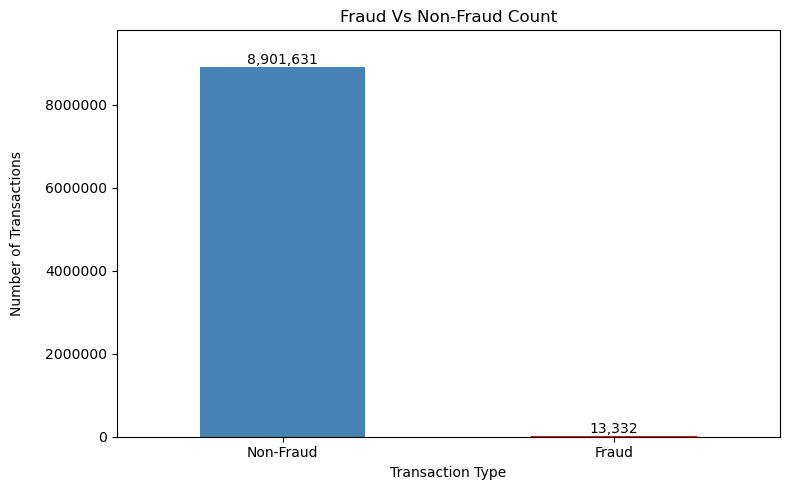

In [43]:
# Fraud Vs Non-Fraud Count Plot
plt.figure(figsize=(8, 5))

fraud_count_plot = fraud_count.rename({
    False: 'Non-Fraud',
    True: 'Fraud'
})

ax = fraud_count_plot.plot(
    kind="bar",
    color=["steelblue", "red"]
)

plt.title("Fraud Vs Non-Fraud Count")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions", rotation=90, labelpad=15)
plt.xticks(rotation=0)
plt.ticklabel_format(style="plain", axis="y")
plt.ylim(0, fraud_count_plot.max() * 1.10)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

##### Fraud Percentage

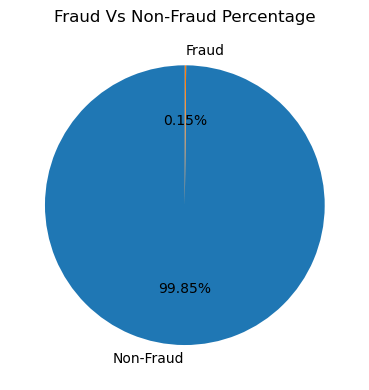

In [44]:
# Fraud Percentage
fraud_percentage = df_isFraud['is_fraud'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))

fraud_percentage = fraud_percentage.rename({
    False: "Non-Fraud",
    True: "Fraud"
})

fraud_percentage.plot(
    kind='pie',
    autopct='%1.2f%%',
    startangle=90,
    ylabel=''
)

plt.title('Fraud Vs Non-Fraud Percentage')
plt.tight_layout()
plt.show()

##### Top 10 Merchant Categories by Fraud Count
Which merchant categories have the highest number of fraudulent transactions?

In [45]:
# Fraud Vs Merchant 
fraud_merchant = df_transaction.merge(df_isFraud,on='id',how='left')
fraud_merchant.value_counts()

id        date                 client_id  card_id  amount   use_chip           merchant_id  merchant_city   merchant_state  zip      mcc                                    errors                is_fraud
7475792   2010-01-01 07:02:00  1424       4710     -72.00   Swipe Transaction  59935        Kingman         AZ              86401.0  Miscellaneous Food Stores              Insufficient Balance  False       1
18250175  2016-08-19 08:41:00  1047       3999      95.01   Chip Transaction   11468        Virginia Beach  VA              23454.0  Artist Supply Stores, Craft Shops      Insufficient Balance  False       1
18249894  2016-08-19 07:35:00  1696       2408      76.00   Chip Transaction   59935        Merritt Island  FL              32953.0  Miscellaneous Food Stores              Technical Glitch      False       1
18249793  2016-08-19 07:11:00  757        3048      80.00   Chip Transaction   27092        Brooklyn        NY              11236.0  Money Transfer                         I

In [46]:
fraud_by_mcc = ( fraud_merchant[fraud_merchant['is_fraud'] == True]['mcc'].value_counts().head(10)  )
fraud_by_mcc

mcc
Department Stores                       2251
Wholesale Clubs                          991
Discount Stores                          859
Money Transfer                           725
Drug Stores and Pharmacies               479
Digital Goods - Media, Books, Apps       449
Grocery Stores, Supermarkets             425
Electronics Stores                       402
Family Clothing Stores                   385
Miscellaneous Home Furnishing Stores     313
Name: count, dtype: int64

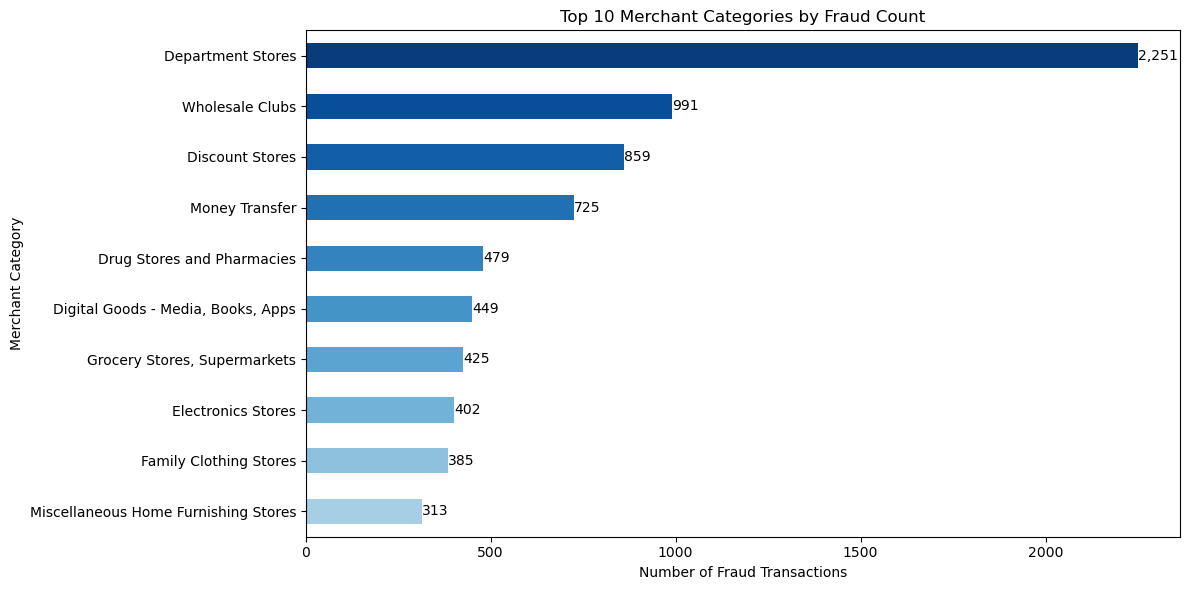

In [47]:
plt.figure(figsize=(12,6))

colors = plt.cm.Blues(np.linspace(0.35, 0.95, len(fraud_by_mcc)))

ax = fraud_by_mcc.sort_values(ascending=True).plot(
    kind='barh',
    color=colors
)

plt.title('Top 10 Merchant Categories by Fraud Count')
plt.xlabel('Number of Fraud Transactions')
plt.ylabel('Merchant Category')

for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width:,.0f}',
        va='center',
        ha='left'
    )

plt.tight_layout()
plt.show()

#####  Top 10 merchant categories by fraud rate
In which categories is fraud most likely?



In [48]:
# fraud rate = fraud transactions / total transactions

merchant_summary_filtered = merchant_summary[merchant_summary['total_transactions'] >= 100]
top_fraud_rate = merchant_summary_filtered.sort_values('fraud_rate', ascending=False).head(10)
top_fraud_rate

,mcc,total_transactions,fraud_transactions,fraud_rate
24,Cruise Lines,276,165,59.782609
73,Music Stores - Musical Instruments,204,76,37.254902
63,Miscellaneous Fabricated Metal Products,245,29,11.836735
22,"Computers, Computer Peripheral Equipment",1883,204,10.833776
40,Floor Covering Stores,222,23,10.36036
67,Miscellaneous Metal Fabrication,256,22,8.59375
35,Electronics Stores,4689,402,8.573257
37,Fabricated Structural Metal Products,273,22,8.058608
82,Precious Stones and Metals,3525,242,6.865248
20,Coated and Laminated Products,260,17,6.538462


<Figure size 1000x700 with 0 Axes>

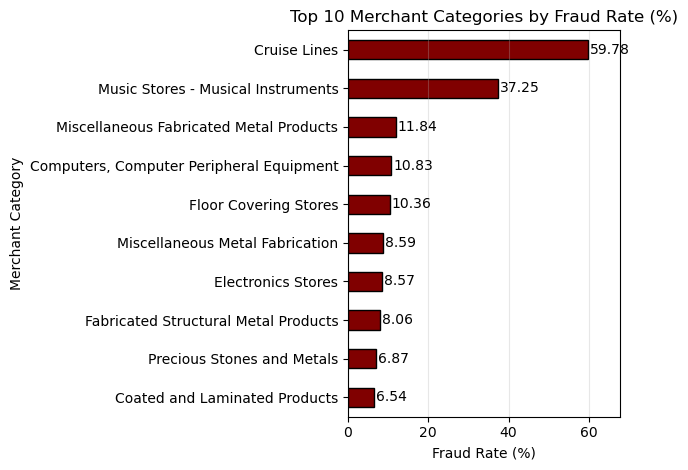

In [49]:
plt.figure(figsize=(10,7))

ax = top_fraud_rate.sort_values('fraud_rate', ascending=True).plot(
    kind='barh',
    x='mcc',
    y='fraud_rate',
    color='maroon',
    edgecolor='black',
    legend=False
)

plt.title('Top 10 Merchant Categories by Fraud Rate (%)')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('Merchant Category')

plt.grid(axis='x', alpha=0.3)

for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}',
        va='center',
        ha='left'
    )

plt.xlim(0, top_fraud_rate['fraud_rate'].max() + 8)

plt.tight_layout()
plt.show()

##### Fraud amount Vs Non-Fraud amount

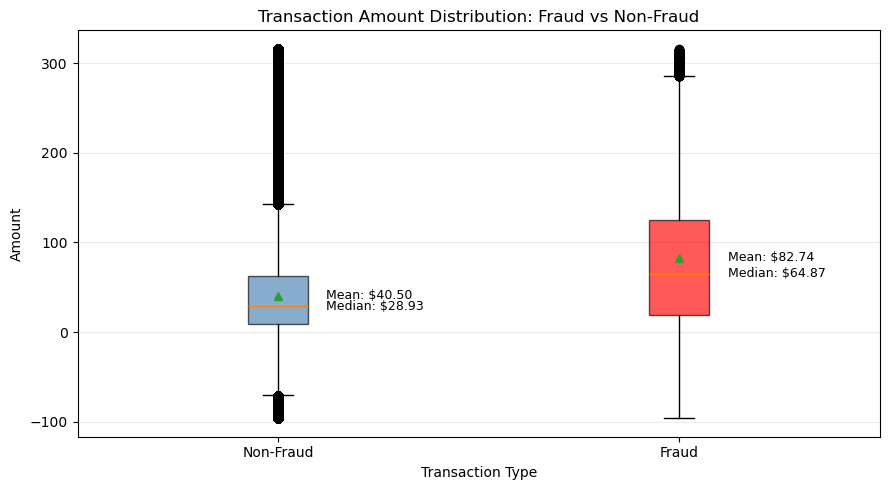

In [50]:
# Amount Distribution: Fraud vs Non-Fraud

amount_compare = fraud_merchant[
    fraud_merchant["is_fraud"].notna()
][["amount", "is_fraud"]].copy()

fraud_amounts = amount_compare[amount_compare["is_fraud"] == True]["amount"]
non_fraud_amounts = amount_compare[amount_compare["is_fraud"] == False]["amount"]

lower_limit = amount_compare["amount"].quantile(0.01)
upper_limit = amount_compare["amount"].quantile(0.99)

fraud_amounts_plot = fraud_amounts[
    (fraud_amounts >= lower_limit) & (fraud_amounts <= upper_limit)
]

non_fraud_amounts_plot = non_fraud_amounts[
    (non_fraud_amounts >= lower_limit) & (non_fraud_amounts <= upper_limit)
]

data = [non_fraud_amounts_plot, fraud_amounts_plot]
labels = ["Non-Fraud", "Fraud"]
colors = ["steelblue", "red"]

plt.figure(figsize=(9, 5))

box = plt.boxplot(
    data,
    tick_labels=labels,
    patch_artist=True,
    showmeans=True
)

for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

for i, values in enumerate(data, start=1):
    mean_value = values.mean()
    median_value = values.median()

    plt.text(
        i + 0.12,
        mean_value,
        f"Mean: ${mean_value:,.2f}",
        va="center",
        fontsize=9
    )

    plt.text(
        i + 0.12,
        median_value,
        f"Median: ${median_value:,.2f}",
        va="center",
        fontsize=9,
        color="black"
    )

plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Transaction Type")
plt.ylabel("Amount")
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

##### Fraud rate by Hour


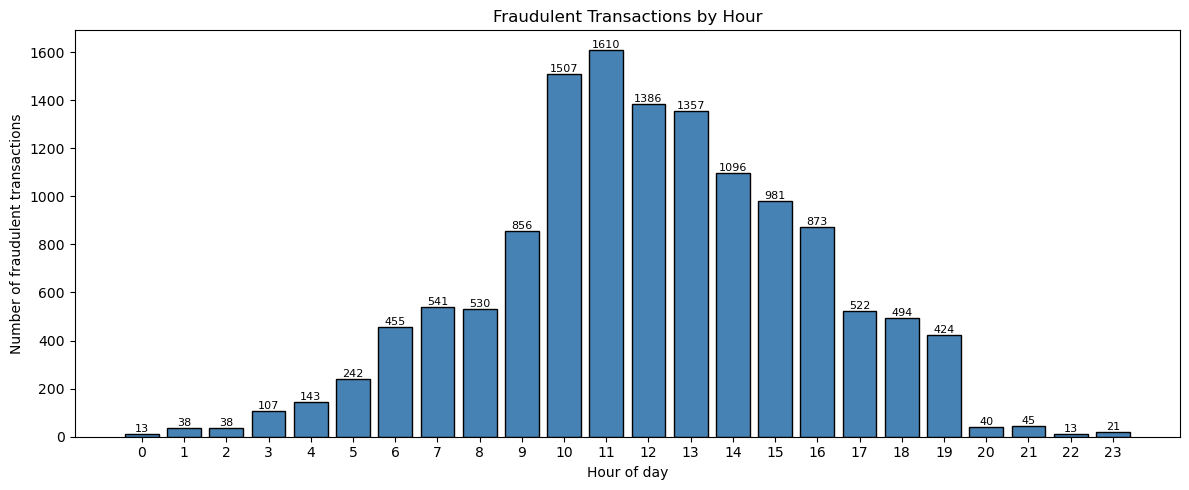

In [51]:
plt.figure(figsize=(12,5))

bars = plt.bar(
    fraud_by_hour['hour'],
    fraud_by_hour['fraud_transactions'],
    color='steelblue',
    edgecolor='black'
)

plt.xticks(range(24))
plt.xlabel("Hour of day")
plt.ylabel("Number of fraudulent transactions")
plt.title("Fraudulent Transactions by Hour")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

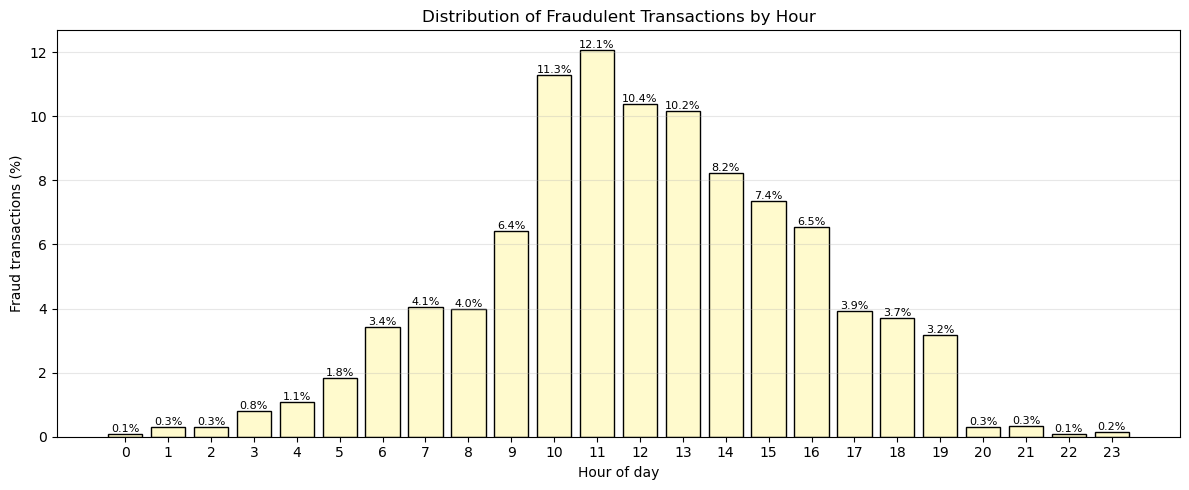

In [52]:
plt.figure(figsize=(12, 5))

bars = plt.bar(
    fraud_by_hour['hour'],
    fraud_by_hour['fraud_percent'],
    color='lemonchiffon',
    edgecolor='black'
)

plt.xticks(range(24))
plt.xlabel('Hour of day')
plt.ylabel('Fraud transactions (%)')
plt.title('Distribution of Fraudulent Transactions by Hour')

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

##### Fraud rate by Day

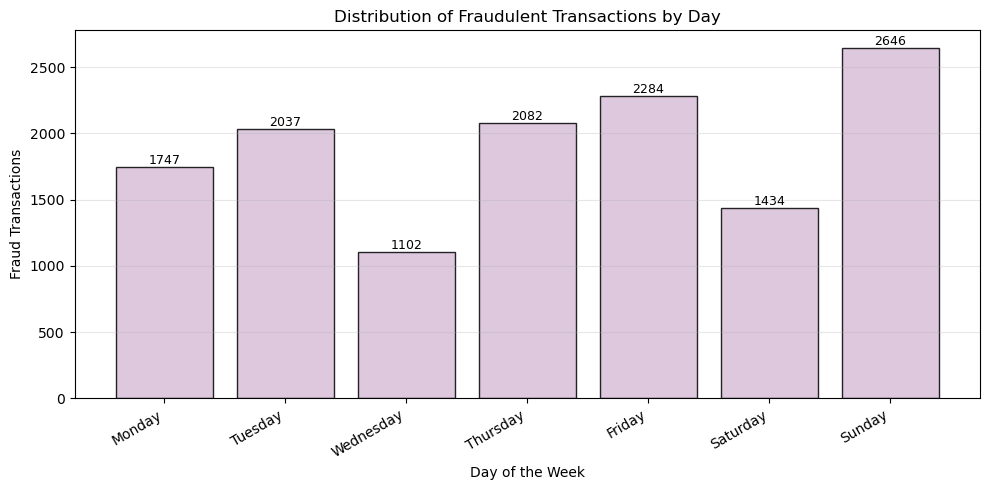

In [53]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    fraud_by_day['day'],
    fraud_by_day['fraud_transactions'],
    color='thistle',
    edgecolor='black',
    alpha=0.85
)

plt.xlabel('Day of the Week')
plt.ylabel('Fraud Transactions')
plt.title('Distribution of Fraudulent Transactions by Day')

plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()  

##### Fraud reate by Card type

In [54]:
# Create a dataframe that has all the data we need ( transactions + fraud labels + card type )

cards_for_merge = df_cards[['id','card_type']].rename(columns={'id':'card_id'})

fraud_card_type = (
    df_transaction
    .merge(df_isFraud, on='id', how='left')
    .merge(cards_for_merge, on='card_id', how='left')
)

# Keep only transactions that have the fraud label
fraud_card_type_label = fraud_card_type[fraud_card_type['is_fraud'].notna()].copy()

fraud_card_type_label.head()

KeyError: "['id'] not in index"

In [ ]:
card_type_summary =(
    fraud_card_type_label.groupby('card_type')
    .agg(
        total_transactions=('id', 'count'),
        fraud_transactions=('is_fraud','sum')
    ).reset_index()
)

card_type_summary['fraud_rate'] = ( card_type_summary['fraud_transactions'] / card_type_summary['total_transactions'] * 100 )
card_type_summary = card_type_summary.sort_values('fraud_rate', ascending=False)

card_type_summary['fraud_per_10000'] = ( card_type_summary['fraud_transactions'] / card_type_summary['total_transactions'] * 10000 )
card_type_summary = card_type_summary.sort_values('fraud_per_10000', ascending=False)
card_type_summary


In [ ]:
plt.figure(figsize=(8,5))

colors = ['bisque', "lavender", "mintcream"]

ax = card_type_summary.plot(
    kind='bar',
    x='card_type',
    y='fraud_per_10000',
    color=colors[:len(card_type_summary)],
    edgecolor='black',
    legend=False,
    figsize=(8,5)
)

plt.title('Fraud Rate by Card Type per 10,000 Transacions')
plt.xlabel('Card type')
plt.ylabel('Fraud rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.3f}%',
        ha='center',
        va='bottom',
        fontsize=9
)
    
plt.tight_layout()
plt.show()

##### Fraud rate by transaction method

In [ ]:
# Fraud rate by transaction method

transaction_method_summary = (
    fraud_merchant_labeled
    .assign(
        transaction_method=fraud_merchant_labeled['use_chip']
        .str.replace(' Transaction', '', regex=False)
        .str.strip()
    )
    .groupby('transaction_method')
    .agg(
        total_transactions=('id', 'count'),
        fraud_transactions=('is_fraud', 'sum')
    )
    .reset_index()
)

transaction_method_summary['fraud_rate'] = (
    transaction_method_summary['fraud_transactions'] 
    / transaction_method_summary['total_transactions'] 
    * 100
)

transaction_method_summary['fraud_per_10000'] = (
    transaction_method_summary['fraud_transactions'] 
    / transaction_method_summary['total_transactions'] 
    * 10000
)

transaction_method_summary = transaction_method_summary.sort_values(
    'fraud_per_10000',
    ascending=False
)

transaction_method_summary

In [ ]:
plt.figure(figsize=(8, 5))

colors = ['bisque', 'lavender', 'mintcream']

ax = transaction_method_summary.plot(
    kind='bar',
    x='transaction_method',
    y='fraud_per_10000',
    color=colors[:len(transaction_method_summary)],
    edgecolor='black',
    legend=False,
    figsize=(8, 5)
)

plt.title('Fraud Rate by Transaction Method per 10,000 Transactions')
plt.xlabel('Transaction method')
plt.ylabel('Fraudulent transactions per 10,000')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()



##### Fraud rate by age group


In [ ]:
age_bins = [17,24,34,44,54,64,100]
age_labels = ['18-24','25-34','35-44','45-54','55-64','65+']

fraud_by_age_df['age_group']= pd.cut(
    fraud_by_age_df['current_age'],
    bins=age_bins,
    labels=age_labels,
    right=True
)

fraud_by_age_df['age_group'].value_counts()

In [ ]:
fraud_by_age_summary = (
    fraud_by_age_df
    .dropna(subset=['age_group'])
    .groupby('age_group', observed=False)
    .agg(
        total_transaction=('id','count'),
        fraud_transaction=('is_fraud','sum')
    )
    .reset_index()
)

fraud_by_age_summary['fraud_rate'] = (fraud_by_age_summary['fraud_transaction'] / fraud_by_age_summary['total_transaction'] *  10000 )

fraud_by_age_summary.head()

In [ ]:
plt.figure(figsize=(8,5))

ax = fraud_by_age_summary.plot(
    kind='bar',
    x='age_group',
    y='fraud_rate',
    color='lightsteelblue',
    edgecolor='black',
    legend=False
)

plt.title('Fraud rate by Age group per 10,000 Transactions')
plt.xlabel('Age group')
plt.ylabel('Fraud rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()